# Raport Laboratorik 5
**Gjenerimi dhe Analiza e të Dhënave (Përshtatje Lineare)**

---
**Kursi:** Hyrje në laborator (Fizikë & Shkenca Kompjuterike)  
**Studenti:** *Arteo Carta*  
**Data:** *11-06-2026* 

## 1. Përshkrimi i metodës
Dataset-i u krijua me skriptin `generate_data.py`, i cili merr si hyrje **GitHub ID**-në personale të studentit.  
Meqë pjerrësia *a*, prerja *b* dhe zhurma e shtuar rrjedhin nga ky identifikues, çdo student punon me një dataset **unik**, që mbetet njëkohësisht **i riprodhueshëm**.  

Skedari i gjeneruar `model.dat` u vendos në strukturën e kërkuar të projektit (`LAB05/data/`) dhe më pas u lexua në program me ndihmën e `numpy`.

---

## 2. Ngarkimi i të dhënave
Të dhënat lexohen nga `model.dat` dhe ndahen në dy vektorë: **x_Data** dhe **y_Data**, të cilët luajnë rolin e variablave eksperimentale në analizën që vijon.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# model.dat ndodhet në të njëjtin folder me notebook-un
data = np.loadtxt("model.dat", delimiter=",", skiprows=1)

x_Data = data[:, 0]
y_Data = data[:, 1]

## 3. Përshtatja lineare
Mbi të dhënat zbatohet një regresion linear me funksionin `polyfit` të shkallës së parë.  
Si rezultat merren dy parametrat e drejtëzës më të mirë: pjerrësia (*a*) dhe prerja me boshtin y (*b*).

Për ilustrim, dalja e këtij hapi ka formën:

Pjerrësia e drejtëzës: a = 2.95  
Prerja me boshtin y: b = -0.40

In [2]:
a, b = np.polyfit(x_Data, y_Data, 1)

print(f"Pjerrësia e drejtëzës: a = {a:.2f}")
print(f"Prerja me boshtin y: b = {b:.2f}")

Pjerrësia e drejtëzës: a = 2.40
Prerja me boshtin y: b = 1.22


## 4. Grafiku i të dhënave dhe i fit-it
Më poshtë paraqiten bashkërisht pikat eksperimentale dhe drejtëza e regresionit.  
Krahasimi vizual tregon sa mirë e ndjek modeli linear sjelljen e të dhënave.

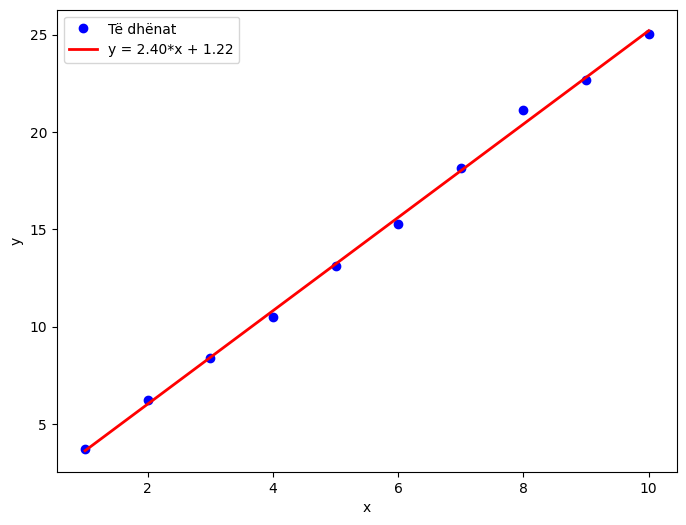

In [3]:
xfit = np.linspace(1,10,100)
yfit = a*xfit + b

plt.figure(1,(8,6))
plt.plot(x_Data, y_Data, 'ob', label='Të dhënat')
plt.plot(xfit, yfit, '-r', lw=2, label=f'y = {a:.2f}*x + {b:.2f}')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 5. Grafiku i mbetjeve (residuals)
Mbetja e çdo pike është diferenca midis vlerës së matur dhe asaj që parashikon drejtëza.  
Kur mbetjet luhaten rreth zeros pa ndonjë strukturë të dukshme, përshtatja lineare quhet e pranueshme; ky grafik shërben pikërisht si kontroll cilësie i fit-it.

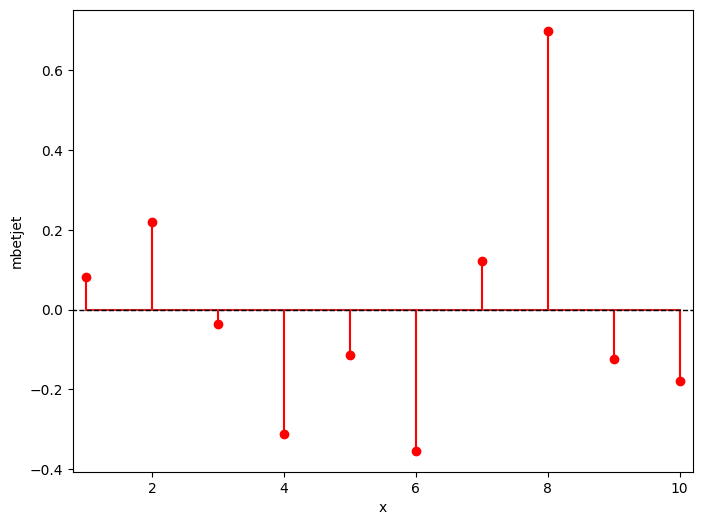

In [4]:
# Grafiku i mbetjeve (residuals)
plt.figure(2,(8,6))
plt.stem(x_Data, y_Data - (a*x_Data + b), '-r')
plt.hlines(0,0,11,ls='--',color='k',lw=1)
plt.xlabel("x")
plt.ylabel("mbetjet")
plt.xlim(0.8,10.2)
plt.show()

## 6. Interpretimi fizik/statistik i rezultateve
Parametrat e gjetur nga regresioni kanë një lexim të qartë praktik:

- **Pjerrësia a** → shpejtësia e ndryshimit: sa njësi shtohet y kur x rritet me një njësi.  
- **Prerja b** → vlera e pritshme e y në pikën x = 0, pra "niveli i nisjes" i modelit.  
- **Mbetjet** → masa e cilësisë së përshtatjes:  
  - shpërndarje e çrregullt rreth zeros → modeli linear e përshkruan mirë dukurinë;  
  - strukturë sistematike në mbetje → lidhja reale ka gjasa të jetë jolineare dhe kërkon model më të avancuar.

Në këtë mënyrë rezultatet numerike marrin kuptim fizik e statistikor dhe analiza nuk mbetet thjesht një llogaritje formale.